In [1]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 



In [4]:
#step1 create sample dataset 

data ={
    'Hours_Studied' : [1,2,3,4,5,6,7,8,9,10],
    'Sleep_Hours':[8,7,6,6,5,5,4,3,3,2],
    'Result':['Fail','Fail','Fail','Fail','Pass','Pass','Pass','Pass','Pass','Pass']
    }

df = pd.DataFrame(data)
print(df)


X=df[['Hours_Studied','Sleep_Hours']]
y=df['Result']


   Hours_Studied  Sleep_Hours Result
0              1            8   Fail
1              2            7   Fail
2              3            6   Fail
3              4            6   Fail
4              5            5   Pass
5              6            5   Pass
6              7            4   Pass
7              8            3   Pass
8              9            3   Pass
9             10            2   Pass


In [5]:
#step 2  Train Test Spilt

X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.3, random_state=42)

Predictions: ['Pass' 'Fail' 'Pass']

Confusion Matrix:
 [[1 0]
 [0 2]]

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



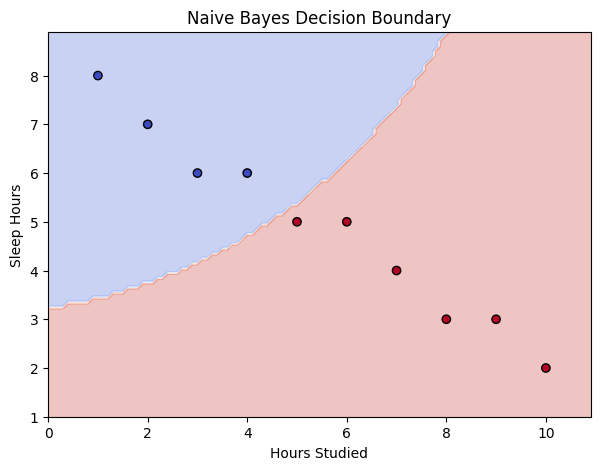

In [8]:
# ----------------------------
# Step 3: Train Naive Bayes
# ----------------------------
model = GaussianNB()
model.fit(X_train, y_train)

# ----------------------------
# Step 4: Make predictions
# ----------------------------
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

# ----------------------------
# Step 5: Evaluate the model
#-----------------------------
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ----------------------------
# Step 6: Visualization
# ----------------------------

plt.figure(figsize=(7,5))

x_min, x_max = X['Hours_Studied'].min() - 1, X['Hours_Studied'].max() + 1
y_min, y_max = X['Sleep_Hours'].min() - 1, X['Sleep_Hours'].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1))


Z = model.predict(pd.DataFrame(np.c_[xx.ravel(), yy.ravel()],columns=X.columns ))



#Encode labels to number for contourf 
le =LabelEncoder()
le.fit(model.classes_)
Z= le.transform(Z)
Z=Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3,cmap='coolwarm')
plt.scatter(X['Hours_Studied'], X['Sleep_Hours'], c=le.transform(y),cmap='coolwarm', edgecolors='k')

plt.xlabel("Hours Studied")
plt.ylabel("Sleep Hours")
plt.title("Naive Bayes Decision Boundary")

plt.show()

In [ ]:
# step 7 : predictor 


#predict for a new student 

new_student =[[6,5]]
result = model.predict(new_student)
print("\n Prediction for new student", result)



 Prediction for new student ['Pass']


c:\Users\Sai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
